In [1]:
# Enable Debugging

%load_ext autoreload
%autoreload 2


In [2]:
import copy
import sys
import os

sys.path.append(os.path.abspath("../../"))
from campaign_diagram import *

In [3]:
# Example usage with multiple Kernel instances
kernel1a = Kernel(name='EinsumA',
                  start=0,
                  duration=3,
                  compute_util=0.7,
                  bw_util=0.25)

kernel1b = Kernel(name='EinsumB',
                  start=kernel1a.end,
                  duration=10,
                  compute_util=0.2,
                  bw_util=0.9)

kernel1c = Kernel(name='EinsumC',
                  start=kernel1b.end,
                  duration=2,
                  compute_util=0.6,
                  bw_util=0.4)

Cascade: Sample Cascade
Kernel(name=EinsumA, start=0.00, duration=3.00, compute_util=0.70, bw_util=0.25
Kernel(name=EinsumB, start=3.00, duration=10.00, compute_util=0.20, bw_util=0.90
Kernel(name=EinsumC, start=13.00, duration=2.00, compute_util=0.60, bw_util=0.40



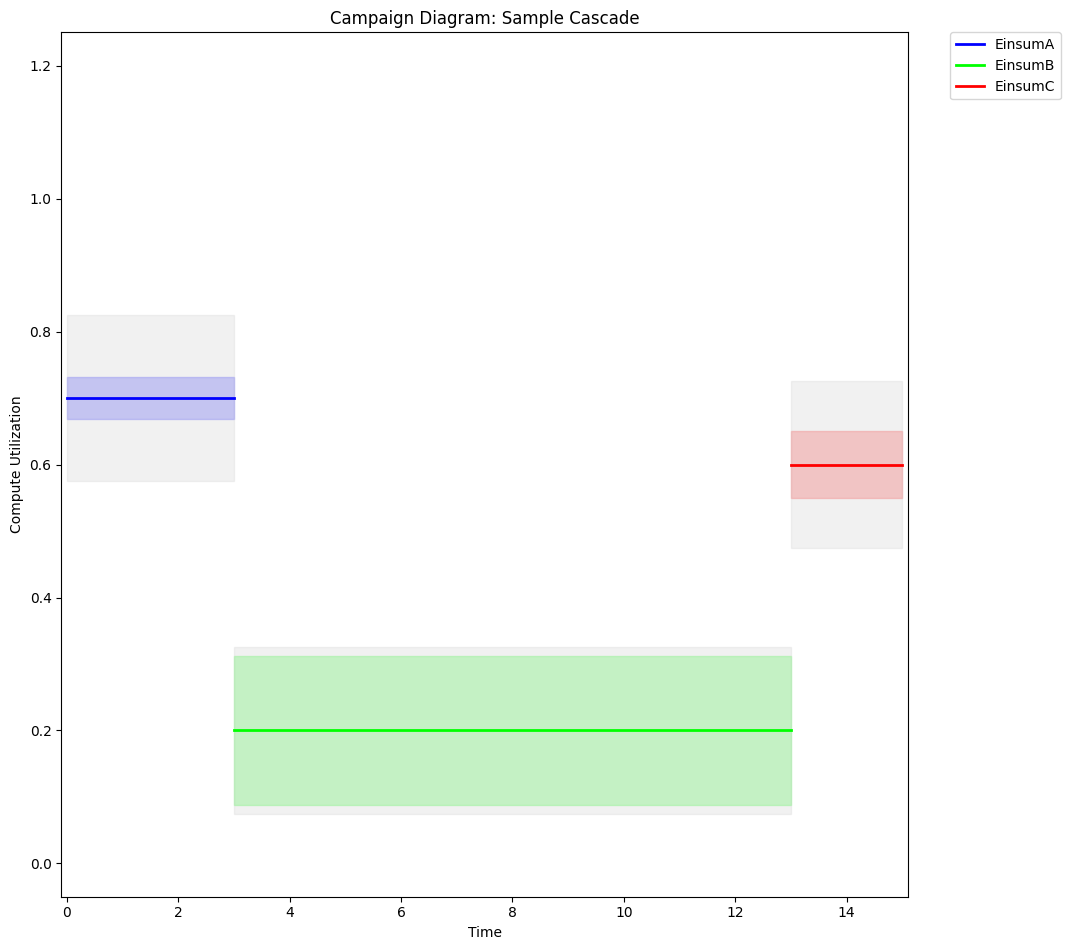

Cascade duration: 15.00
Cascade average compute utilization: 0.35
Cascade average bw utilization: 0.70


In [4]:
# Create the plot with a list of kernel instances
cascade1 = Cascade(name="Sample Cascade",
                   kernels=[kernel1a, kernel1b, kernel1c])

cascade1.pretty_print()
campaign_diagram1 = CampaignDiagram(cascade1)
campaign_diagram1.draw()

Cascade: Sequential Cascade
Kernel(name=EinsumA, start=0.00, duration=3.00, compute_util=0.70, bw_util=0.25
Kernel(name=EinsumB, start=3.00, duration=10.00, compute_util=0.20, bw_util=0.90
Kernel(name=EinsumA, start=13.00, duration=3.00, compute_util=0.70, bw_util=0.25
Kernel(name=EinsumB, start=16.00, duration=10.00, compute_util=0.20, bw_util=0.90
Kernel(name=EinsumA, start=26.00, duration=3.00, compute_util=0.70, bw_util=0.25
Kernel(name=EinsumB, start=29.00, duration=10.00, compute_util=0.20, bw_util=0.90
Kernel(name=EinsumA, start=39.00, duration=3.00, compute_util=0.70, bw_util=0.25
Kernel(name=EinsumB, start=42.00, duration=10.00, compute_util=0.20, bw_util=0.90



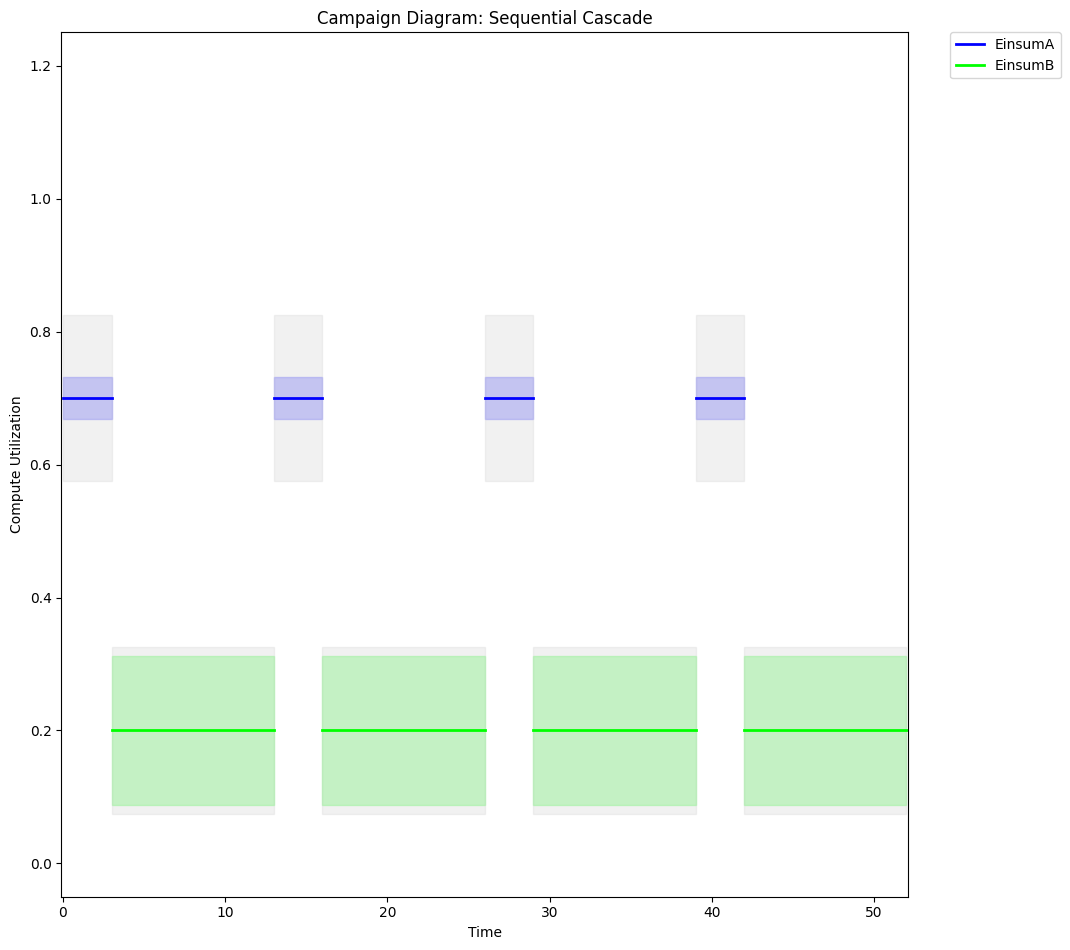

Cascade duration: 52.00
Cascade average compute utilization: 0.32
Cascade average bw utilization: 0.75


In [5]:
# Show replicated sequence

kernel2a = Kernel(name='EinsumA',
                  duration=3,
                  compute_util=0.7,
                  bw_util=0.25)

kernel2b = Kernel(name='EinsumB',
                  duration=10,
                  compute_util=0.2,
                  bw_util=0.9)

kernels2 = [kernel.clone() for kernel in 4*[kernel2a, kernel2b]]

cascade2 = Cascade(name="Sequential Cascade",
                   kernels=kernels2,
                   sequential=True)

cascade2.pretty_print()
campaign_diagram = CampaignDiagram(cascade2)
campaign_diagram.draw()